# 1.Dataset Loading and Initial Cleaning

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the data
df = pd.read_csv('train.csv')

In [3]:
# Inspect the dataset
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
print("Data Types and Nulls:")
df.info()

Dataset Shape: (1460, 81)
------------------------------
Data Types and Nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     14

In [4]:
# Check for missing values count
missing_data = df.isnull().sum()
print("-" * 30)
print("Columns with missing values:")
print(missing_data[missing_data > 0].sort_values(ascending=False))

------------------------------
Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [5]:
# Statistical Summary to spot outliers
print("-" * 30)
print("Statistical Summary:")
display(df.describe())

------------------------------
Statistical Summary:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


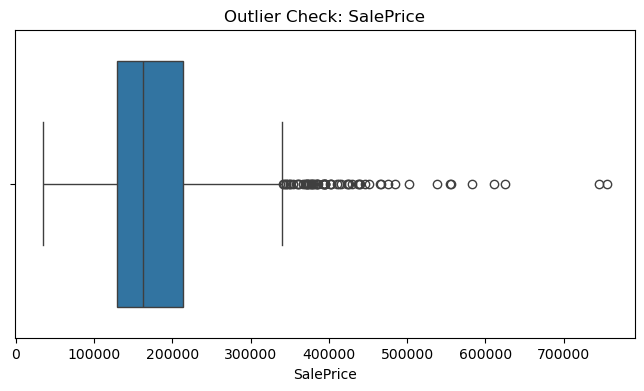

In [6]:
# Visualizing SalePrice outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['SalePrice'])
plt.title('Outlier Check: SalePrice')
plt.show()

# 2.Analysis of Missing Values

Following an assessment of the dataset, several columns are identified as having significant missing values. In data science, when a column is missing more than 40% of its data, the information loss is often too high to reliably impute; therefore, dropping these features is the recommended approach to maintain model integrity.

## Cleaning Actions

### Drop Columns (Excessive Nulls)
These features lack sufficient data density to be useful for predictive modeling.
* `PoolQC`
* `MiscFeature`
* `Alley`
* `Fence`

### Impute Numeric Values
For continuous variables with moderate missingness, using **median** to avoid bias from outliers.
* `LotFrontage`
* `MasVnrArea`

### Impute Categorical Values
For these features, missing values represent the absence of an attribute (e.g., no garage or no basement). We will fill these with a placeholder label.
* **Filling Value:** `'None'` or `'Missing'`
* **Target Columns:** `MasVnrType`, `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`.

### Special Case Handling
Specific domain knowledge is required for these columns:
* **`GarageYrBlt`**: Filling  with `YearBuilt` (assuming the garage was constructed alongside the home).
* **`Electrical`**: Filling  with the **mode** (most frequent value) to represent the standard configuration.

# 3. Implementation Code

In [7]:
# Create a copy to keep original data safe
df_clean = df.copy()

In [8]:
# Drop columns with excessive missing values
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
df_clean.drop(columns=cols_to_drop, inplace=True)

In [9]:
# Fill Categorical features
cat_cols = ['MasVnrType', 'FireplaceQu', 'GarageType', 'GarageFinish', 
            'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
            'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('None')

In [10]:
# Fill Numerical features
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(df_clean['YearBuilt'])

In [11]:
# Fill 'Electrical' with mode (the most common value)
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

In [12]:
# Verify no nulls are left
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Missing values remaining: 0


# 4. Outlier Handling
Based on the `describe()` summary, the `SalePrice` exhibits significant variance: the maximum value is 755,000, while the 75th percentile is 214,000. 

* **Analysis:** These extreme high-end values are technically outliers, but in the context of real estate, they represent legitimate "luxury" property data points.
* **Recommendation:** Keep these values for the initial training phase. If the model performance is suboptimal, revisit this step to potentially drop rows where `SalePrice > 500,000`.

# 5. Final Step of Phase 1

In [13]:
# Export to use for Phase 2
df_clean.to_csv('gold_housing_data.csv', index=False)
print("Gold dataset saved successfully!")

Gold dataset saved successfully!
